
<b><h2>Pillar 5: Capstone Project</h2></b>

<p>
Submitted by: <b>Darwin A. Nepomuceno</b>
</p>
<p>
<b>Post Graduate Diploma in Artificial Intelligence and Machine Learning</b>
</p>

___


# 🎯 **PHASE 04 | CTG — Threshold Optimization & Validation**

## **Goal: Find the optimal decision boundary that minimises clinical cost.**

> A model's default `predict()` uses a 0.5 probability threshold — but that threshold
> is arbitrary and ignores the FN/FP cost asymmetry. This phase searches for the
> threshold that actually minimises `Cost = FP×1 + FN×10`.

| Step | What |
|------|------|
| 1 | Stratified 5-Fold CV on the best model from Phase 03 |
| 2 | Sweep thresholds 0.1 → 0.9, plot Cost vs. Threshold |
| 3 | Select optimal threshold (min cost, or Recall ≥ 95% + max Precision) |
| 4 | Final evaluation: Confusion Matrix, ROC Curve, Precision-Recall Curve |

## 0 · Imports & Setup

In [1]:
import warnings
from typing import cast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection  import StratifiedKFold, cross_validate
from sklearn.metrics          import (accuracy_score, precision_score, recall_score, f1_score,
                                      confusion_matrix, classification_report, ConfusionMatrixDisplay,
                                      make_scorer, roc_curve, roc_auc_score,
                                      precision_recall_curve, average_precision_score)
import xgboost as xgb
import pickle



print('Libraries loaded ✓  (data loading handled via Phase 02 pickle — see Section 1)')

Libraries loaded ✓  (data loading handled via Phase 02 pickle — see Section 1)


In [2]:
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE = {0: '#2196F3', 1: '#F44336'}
LABEL   = {0: 'Normal',  1: 'Abnormal'}
SEED    = 42

## 1 · Load Preprocessed Data from Phase 02 & Reinstantiate Best Model

> Loads `ctg_preprocessed.pkl` (produced by Phase 02's final cell) for the exact
> same train/test split and fitted scaler used throughout the pipeline.
> Best model from Phase 03 comparison: **XGBoost with `scale_pos_weight`**.

In [3]:
# ── Load preprocessed data from Phase 02 ──────────────────────────────────────
# Loads the EXACT same train/test split, fitted scaler, and resampled arrays
# produced in Phase 02 — guarantees byte-identical data across all phases.


PICKLE_PATH =  '../04 misc/ctg_preprocessed.pkl'

try:
    with open(PICKLE_PATH, 'rb') as f:
        prep = pickle.load(f)
except FileNotFoundError as e:
    raise FileNotFoundError(
        f"'{PICKLE_PATH}' not found. Run the Phase 02 preprocessing notebook "
        f"first — its final cell saves this pickle file in the same directory."
    ) from e

X_train_scaled = prep['X_train_scaled']
y_train        = prep['y_train']
X_test_scaled  = prep['X_test_scaled']
y_test         = prep['y_test']
FEATURES       = prep['feature_names']
scaler         = prep['scaler']

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
 
y_train = pd.Series(y_train, name='target')
y_test  = pd.Series(y_test,  name='target')

# ── Best model from Phase 03 ───────────────────────────────────────────────────
best_model = xgb.XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    verbosity=0,
    random_state=SEED,
)

print(f'Loaded from {PICKLE_PATH}')
print(f'X_train_scaled : {X_train_scaled.shape}')
print(f'X_test_scaled  : {X_test_scaled.shape}')
print(f'scale_pos_weight : {scale_pos_weight:.4f}')
print('Best model : XGBoost (scale_pos_weight strategy)')

Loaded from ../04 misc/ctg_preprocessed.pkl
X_train_scaled : (1691, 21)
X_test_scaled  : (423, 21)
scale_pos_weight : 3.5335
Best model : XGBoost (scale_pos_weight strategy)


## 2 · Cost Function (same definition as Phase 03)

In [4]:
def compute_cost(y_true, y_pred):
    """Clinical cost: FP\u00d71 + FN\u00d710. Lower is better."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return int(fp * 1 + fn * 10)

In [5]:
def cost_scorer_fn(y_true, y_pred):
    """
    Sklearn scorer function: returns RAW (positive) cost.
    IMPORTANT: make_scorer(..., greater_is_better=False) already negates the
    score internally for sklearn's 'higher is better' convention -- this
    function must NOT pre-negate, or the sign gets flipped twice.
    """
    return compute_cost(y_true, y_pred)

custom_score = make_scorer(cost_scorer_fn, greater_is_better=False)

In [6]:

# Sanity check
assert compute_cost(np.array([0,0,1,1,1]), np.array([0,1,0,0,1])) == 21
print('Cost function verified \u2713  (1 FP + 2 FN \u2192 21)')
print('custom_score reports NEGATIVE cost internally (sklearn convention);')
print('negate again when displaying: actual_cost = -cv_results[\'test_cost\']')

Cost function verified ✓  (1 FP + 2 FN → 21)
custom_score reports NEGATIVE cost internally (sklearn convention);
negate again when displaying: actual_cost = -cv_results['test_cost']


---
## 3 · Stratified 5-Fold Cross-Validation

**What it does :** Validates that the model's Recall/Cost performance is stable across folds,
not a lucky artifact of one particular train/test split.

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

scoring = {
    'recall'   : 'recall',
    'precision': 'precision',
    'f1'       : 'f1',
    'cost'     : custom_score,
}

cv_results = cross_validate(
    best_model, X_train_scaled, y_train,
    cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)

recall_mean = cv_results['test_recall'].mean()
recall_std  = cv_results['test_recall'].std()
cost_mean   = -cv_results['test_cost'].mean()   # negate back to positive cost
cost_std    = cv_results['test_cost'].std()      # std unaffected by sign flip
f1_mean     = cv_results['test_f1'].mean()
prec_mean   = cv_results['test_precision'].mean()

print('Stratified 5-Fold CV Results (Best Model: XGBoost)')
print('=' * 55)
print(f'  Recall    : {recall_mean:.4f} ± {recall_std:.4f}')
print(f'  Precision : {prec_mean:.4f}')
print(f'  F1        : {f1_mean:.4f}')
print(f'  Cost      : {cost_mean:.2f} ± {cost_std:.2f}')
print()
print('  Per-fold costs:', [-c for c in cv_results['test_cost']])
print('  Per-fold recall:', cv_results['test_recall'].round(3).tolist())

Stratified 5-Fold CV Results (Best Model: XGBoost)
  Recall    : 0.8928 ± 0.0446
  Precision : 0.9181
  F1        : 0.9046
  Cost      : 86.00 ± 34.05

  Per-fold costs: [np.int64(63), np.int64(90), np.int64(83), np.int64(147), np.int64(47)]
  Per-fold recall: [0.92, 0.892, 0.892, 0.813, 0.947]


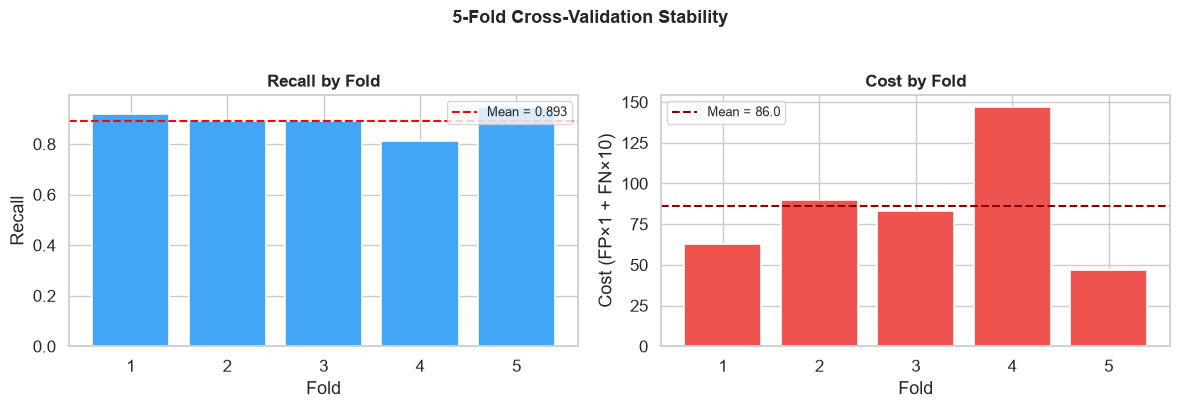

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fold_nums = np.arange(1, 6)

axes[0].bar(fold_nums, cv_results['test_recall'], color='#42A5F5',
            edgecolor='white', linewidth=1.2)
axes[0].axhline(recall_mean, color='red', linestyle='--', linewidth=1.5,
                label=f'Mean = {recall_mean:.3f}')
axes[0].set_title('Recall by Fold', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Recall')
axes[0].set_xticks(fold_nums)
axes[0].legend(fontsize=9)

fold_costs = [-c for c in cv_results['test_cost']]
axes[1].bar(fold_nums, fold_costs, color='#EF5350',
            edgecolor='white', linewidth=1.2)
axes[1].axhline(cost_mean, color='darkred', linestyle='--', linewidth=1.5,
                label=f'Mean = {cost_mean:.1f}')
axes[1].set_title('Cost by Fold', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Cost (FP×1 + FN×10)')
axes[1].set_xticks(fold_nums)
axes[1].legend(fontsize=9)

plt.suptitle('5-Fold Cross-Validation Stability', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 4 · Threshold Tuning

**What it does :** Fit the model on the full training set, then sweep decision thresholds
from 0.1 to 0.9 on the held-out test set probabilities.

In [9]:
best_model.fit(X_train_scaled, y_train)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

print(f'y_proba shape : {y_proba.shape}')
print(f'Probability range : [{y_proba.min():.4f}, {y_proba.max():.4f}]')

# Default threshold (0.5) performance, for comparison later
y_pred_default = (y_proba >= 0.5).astype(int)
default_cost   = compute_cost(y_test, y_pred_default)
print(f'\nDefault (0.5) threshold → Cost: {default_cost}, '
      f'Recall: {recall_score(y_test, y_pred_default):.4f}')

y_proba shape : (423,)
Probability range : [0.0000, 1.0000]

Default (0.5) threshold → Cost: 84, Recall: 0.9140


In [10]:
# ── Threshold sweep: 0.1 → 0.9 ────────────────────────────────────────────────
thresholds = np.arange(0.10, 0.91, 0.01)
threshold_results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t, labels=[0, 1]).ravel()
    cost = fp * 1 + fn * 10
    threshold_results.append({
        'Threshold' : round(t, 2),
        'Cost'      : cost,
        'Recall'    : recall_score(y_test, y_pred_t, zero_division=0),
        'Precision' : precision_score(y_test, y_pred_t, zero_division=0),
        'F1'        : f1_score(y_test, y_pred_t, zero_division=0),
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
    })

df_thresh = pd.DataFrame(threshold_results)
print(f'Swept {len(df_thresh)} thresholds from {thresholds[0]:.2f} to {thresholds[-1]:.2f}')
df_thresh.head(10)

Swept 81 thresholds from 0.10 to 0.90


,Threshold,Cost,Recall,Precision,F1,TP,FP,TN,FN
0,0.10,49,0.956989,0.908163,0.931937,89,9,321,4
1,0.11,49,0.956989,0.908163,0.931937,89,9,321,4
2,0.12,49,0.956989,0.908163,0.931937,89,9,321,4
3,0.13,59,0.946237,0.907216,0.926316,88,9,321,5
4,0.14,59,0.946237,0.907216,0.926316,88,9,321,5
5,0.15,58,0.946237,0.916667,0.931217,88,8,322,5
6,0.16,77,0.924731,0.924731,0.924731,86,7,323,7
7,0.17,77,0.924731,0.924731,0.924731,86,7,323,7
8,0.18,87,0.913978,0.923913,0.918919,85,7,323,8
9,0.19,87,0.913978,0.923913,0.918919,85,7,323,8


In [11]:
# ── Select optimal threshold ──────────────────────────────────────────────────
# Strategy A: minimum cost
min_cost_idx       = df_thresh['Cost'].idxmin()
optimal_min_cost    = df_thresh.loc[min_cost_idx, 'Threshold']
optimal_min_cost_val= df_thresh.loc[min_cost_idx, 'Cost']

# Strategy B: Recall >= 95% with max Precision among those
df_high_recall = df_thresh[df_thresh['Recall'] >= 0.95]
if not df_high_recall.empty:
    best_hr_idx        = df_high_recall['Precision'].idxmax()
    optimal_high_recall = df_thresh.loc[best_hr_idx, 'Threshold']
    has_high_recall_opt = True
else:
    optimal_high_recall = None
    has_high_recall_opt = False

print('Threshold Selection')
print('=' * 55)
print('  Strategy A — Min Cost')
print(f'    Threshold : {optimal_min_cost}')
print(f'    Cost      : {optimal_min_cost_val}')
print(f'    Recall    : {df_thresh.loc[min_cost_idx, "Recall"]:.4f}')
print(f'    Precision : {df_thresh.loc[min_cost_idx, "Precision"]:.4f}')
print()
if has_high_recall_opt:
    print('  Strategy B — Recall ≥ 95%, Max Precision')
    print(f'    Threshold : {optimal_high_recall}')
    print(f'    Cost      : {df_thresh.loc[best_hr_idx, "Cost"]}')
    print(f'    Recall    : {df_thresh.loc[best_hr_idx, "Recall"]:.4f}')
    print(f'    Precision : {df_thresh.loc[best_hr_idx, "Precision"]:.4f}')
else:
    print('  Strategy B — No threshold achieves Recall ≥ 95% on this test set.')
    print('  Falling back to Strategy A (min cost).')

# ── Final selected threshold ──────────────────────────────────────────────────
OPTIMAL_THRESHOLD = optimal_high_recall if has_high_recall_opt else optimal_min_cost
print(f'\n🎯  SELECTED THRESHOLD = {OPTIMAL_THRESHOLD}')

optimal_threshold = OPTIMAL_THRESHOLD
%store optimal_threshold

Threshold Selection
  Strategy A — Min Cost
    Threshold : 0.1
    Cost      : 49
    Recall    : 0.9570
    Precision : 0.9082

  Strategy B — Recall ≥ 95%, Max Precision
    Threshold : 0.1
    Cost      : 49
    Recall    : 0.9570
    Precision : 0.9082

🎯  SELECTED THRESHOLD = 0.1
Stored 'optimal_threshold' (float64)


### Cost vs. Threshold Plot

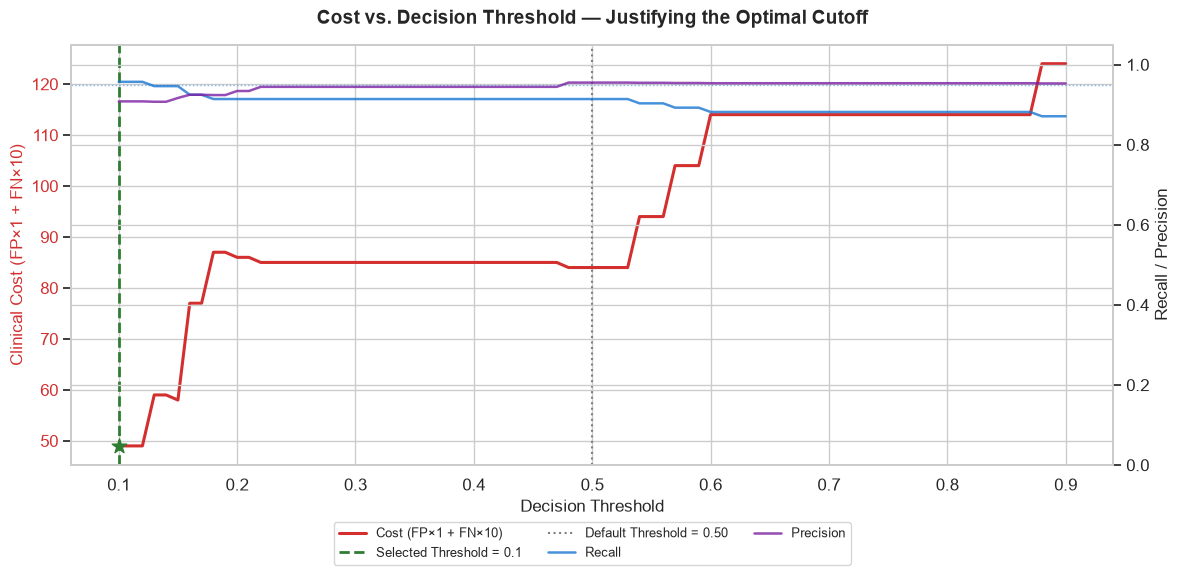

In [12]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Cost curve (left axis)
ax1.plot(df_thresh['Threshold'], df_thresh['Cost'],
         color='#D32F2F', linewidth=2.2, label='Cost (FP×1 + FN×10)')
ax1.axvline(cast(float, OPTIMAL_THRESHOLD), color='#2E7D32', linestyle='--', linewidth=2,
            label=f'Selected Threshold = {OPTIMAL_THRESHOLD}')
ax1.axvline(0.5, color='gray', linestyle=':', linewidth=1.5,
            label='Default Threshold = 0.50')
ax1.scatter([cast(float, OPTIMAL_THRESHOLD)],
            [df_thresh.loc[df_thresh['Threshold']==cast(float, OPTIMAL_THRESHOLD),'Cost'].values[0]],
            color='#2E7D32', s=120, zorder=5, marker='*')
ax1.set_xlabel('Decision Threshold', fontsize=12)
ax1.set_ylabel('Clinical Cost (FP×1 + FN×10)', fontsize=12, color='#D32F2F')
ax1.tick_params(axis='y', labelcolor='#D32F2F')

# Recall / Precision (right axis)
ax2 = ax1.twinx()
ax2.plot(df_thresh['Threshold'], df_thresh['Recall'],
         color='#1976D2', linewidth=1.8, linestyle='-', alpha=0.8, label='Recall')
ax2.plot(df_thresh['Threshold'], df_thresh['Precision'],
         color='#7B1FA2', linewidth=1.8, linestyle='-', alpha=0.8, label='Precision')
ax2.axhline(0.95, color='#1976D2', linestyle=':', linewidth=1, alpha=0.5)
ax2.set_ylabel('Recall / Precision', fontsize=12)
ax2.set_ylim(0, 1.05)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center',
           bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=9.5)

plt.title('Cost vs. Decision Threshold — Justifying the Optimal Cutoff',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

---
## 5 · Final Evaluation at Optimal Threshold

In [13]:
y_pred_optimal = (y_proba >= OPTIMAL_THRESHOLD).astype(int)

print('=' * 60)
print(f'  Final Model Evaluation @ Threshold = {OPTIMAL_THRESHOLD}')
print('=' * 60)
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_optimal):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred_optimal):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred_optimal):.4f}')
print(f'  F1        : {f1_score(y_test, y_pred_optimal):.4f}')
print(f'  Cost      : {compute_cost(y_test, y_pred_optimal)}')
print()
print(classification_report(y_test, y_pred_optimal, target_names=['Normal', 'Abnormal']))

print('Comparison vs Default (0.5) Threshold:')
print(f'  Default  (0.50) → Cost: {default_cost},  '
      f'Recall: {recall_score(y_test, y_pred_default):.4f}')
print(f'  Optimal ({OPTIMAL_THRESHOLD}) → Cost: {compute_cost(y_test, y_pred_optimal)},  '
      f'Recall: {recall_score(y_test, y_pred_optimal):.4f}')
improvement = default_cost - compute_cost(y_test, y_pred_optimal)
print(f'\n  💰 Cost reduction: {improvement} '
      f'({improvement/default_cost*100:.1f}% lower than default threshold)')

  Final Model Evaluation @ Threshold = 0.1
  Accuracy  : 0.9693
  Precision : 0.9082
  Recall    : 0.9570
  F1        : 0.9319
  Cost      : 49

              precision    recall  f1-score   support

      Normal       0.99      0.97      0.98       330
    Abnormal       0.91      0.96      0.93        93

    accuracy                           0.97       423
   macro avg       0.95      0.96      0.96       423
weighted avg       0.97      0.97      0.97       423

Comparison vs Default (0.5) Threshold:
  Default  (0.50) → Cost: 84,  Recall: 0.9140
  Optimal (0.1) → Cost: 49,  Recall: 0.9570

  💰 Cost reduction: 35 (41.7% lower than default threshold)


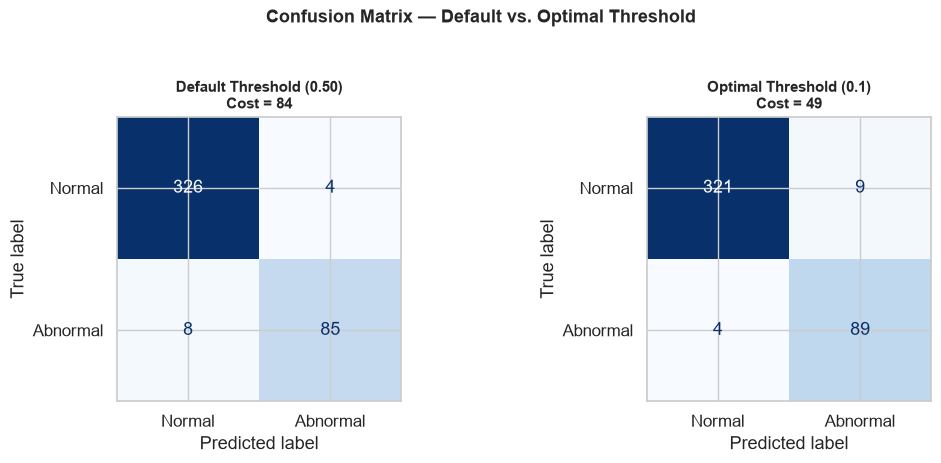

In [14]:
# ── Confusion Matrices: default vs optimal threshold ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (name, pred) in zip(axes, [
    ('Default Threshold (0.50)', y_pred_default),
    (f'Optimal Threshold ({OPTIMAL_THRESHOLD})', y_pred_optimal),
]):
    cm   = confusion_matrix(y_test, pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Abnormal'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    cost = compute_cost(y_test, pred)
    ax.set_title(f'{name}\nCost = {cost}', fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrix — Default vs. Optimal Threshold',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### ROC Curve

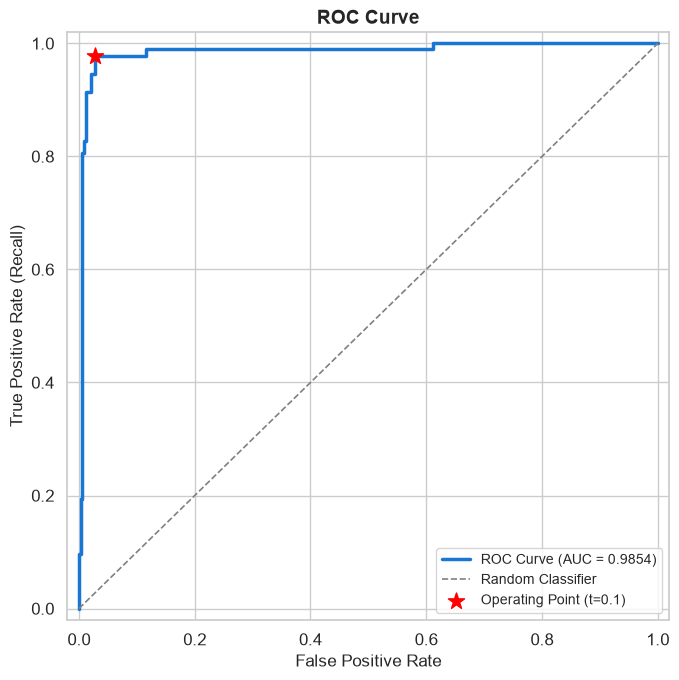

ROC AUC : 0.9854
At operating point (closest available threshold 0.088):
  TPR (Recall) : 0.9785
  FPR          : 0.0273


In [15]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

# Find the point on the ROC curve closest to our chosen operating threshold
idx_closest = int(np.argmin(np.abs(roc_thresholds - OPTIMAL_THRESHOLD)))

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(fpr, tpr, color='#1976D2', linewidth=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.2, label='Random Classifier')
ax.scatter(fpr[idx_closest], tpr[idx_closest], color="#FF0000", s=150, zorder=5,
           marker='*', label=f'Operating Point (t={OPTIMAL_THRESHOLD})')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.show()

print(f'ROC AUC : {roc_auc:.4f}')
print(f'At operating point (closest available threshold {roc_thresholds[idx_closest]:.3f}):')
print(f'  TPR (Recall) : {tpr[idx_closest]:.4f}')
print(f'  FPR          : {fpr[idx_closest]:.4f}')

### Precision-Recall Curve

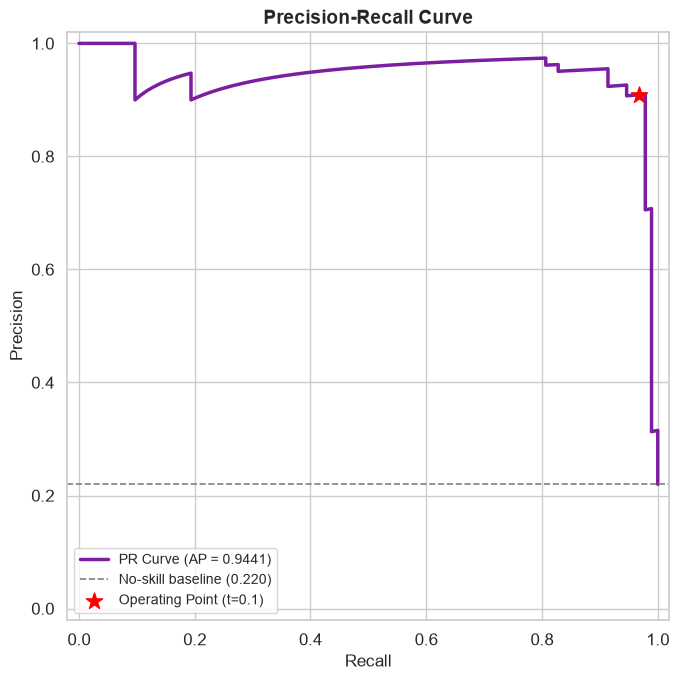

Average Precision (AP) : 0.9441
At operating point (closest available threshold 0.089):
  Precision : 0.9091
  Recall    : 0.9677


In [16]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

# NOTE: pr_thresholds has length len(precision_curve)-1 (sklearn convention).
# Find the index in pr_thresholds closest to our operating threshold.
idx_pr = int(np.argmin(np.abs(pr_thresholds - OPTIMAL_THRESHOLD)))

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(recall_curve, precision_curve, color='#7B1FA2', linewidth=2.5,
        label=f'PR Curve (AP = {avg_precision:.4f})')
baseline_rate = (y_test == 1).mean()
ax.axhline(baseline_rate, color='gray', linestyle='--', linewidth=1.2,
           label=f'No-skill baseline ({baseline_rate:.3f})')
ax.scatter(recall_curve[idx_pr], precision_curve[idx_pr], color="#FF0000", s=150,
           zorder=5, marker='*', label=f'Operating Point (t={OPTIMAL_THRESHOLD})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower left')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.show()

print(f'Average Precision (AP) : {avg_precision:.4f}')
print(f'At operating point (closest available threshold {pr_thresholds[idx_pr]:.3f}):')
print(f'  Precision : {precision_curve[idx_pr]:.4f}')
print(f'  Recall    : {recall_curve[idx_pr]:.4f}')

### Combined Diagnostic Dashboard

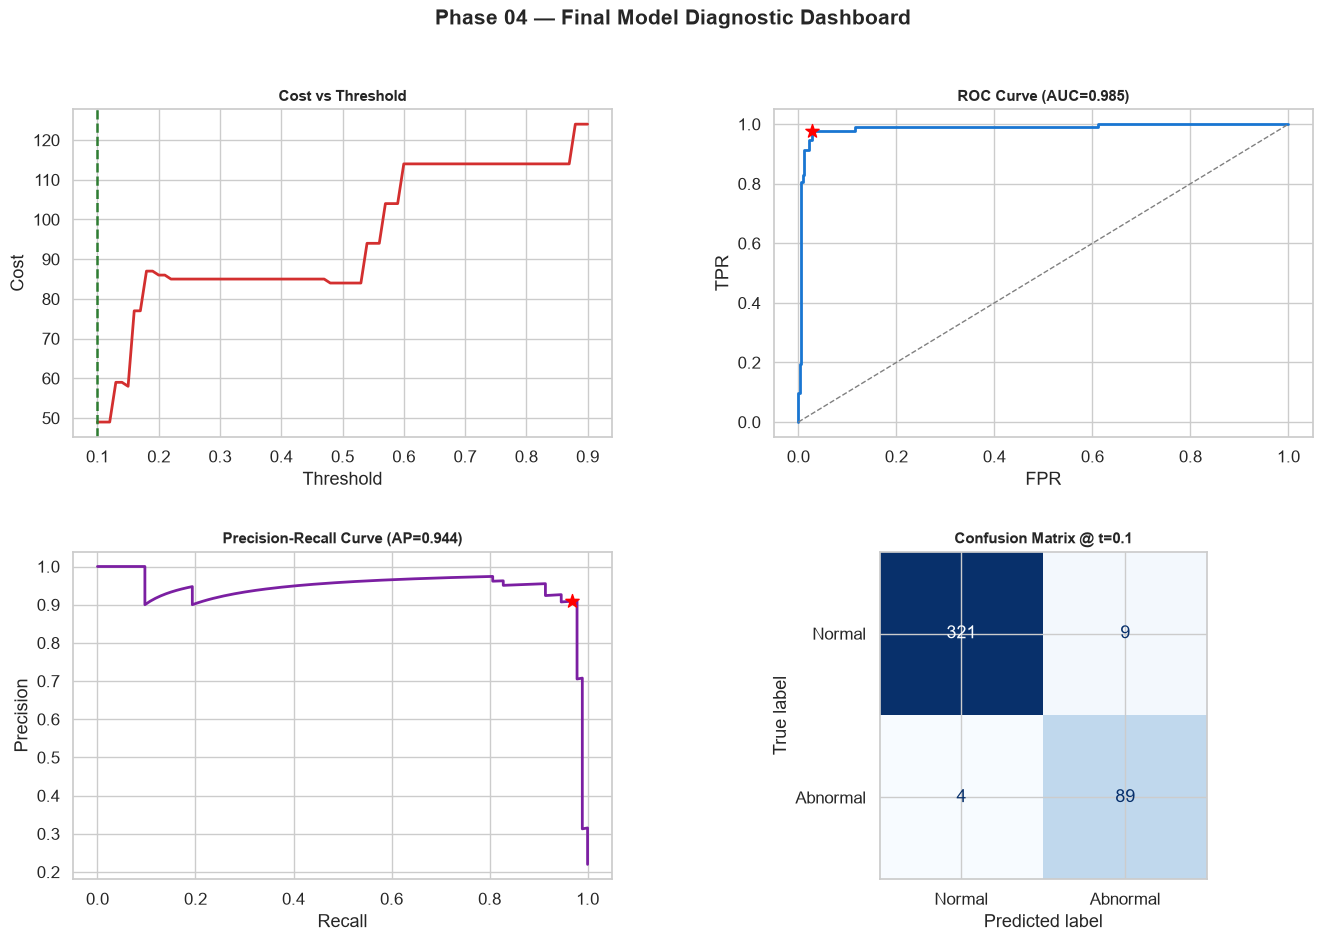

In [17]:
fig = plt.figure(figsize=(16, 10))
gs  = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

# Top-left: Cost vs Threshold
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df_thresh['Threshold'], df_thresh['Cost'], color='#D32F2F', linewidth=2)
ax1.axvline(cast(float,OPTIMAL_THRESHOLD), color='#2E7D32', linestyle='--', linewidth=1.8)
ax1.set_title('Cost vs Threshold', fontsize=11, fontweight='bold')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Cost')

# Top-right: ROC
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(fpr, tpr, color='#1976D2', linewidth=2)
ax2.plot([0,1],[0,1], color='gray', linestyle='--', linewidth=1)
ax2.scatter(fpr[idx_closest], tpr[idx_closest], color="#FF0000", s=100, zorder=5, marker='*')
ax2.set_title(f'ROC Curve (AUC={roc_auc:.3f})', fontsize=11, fontweight='bold')
ax2.set_xlabel('FPR')
ax2.set_ylabel('TPR')

# Bottom-left: PR Curve
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(recall_curve, precision_curve, color='#7B1FA2', linewidth=2)
ax3.scatter(recall_curve[idx_pr], precision_curve[idx_pr], color="#FF0000", s=100, zorder=5, marker='*')
ax3.set_title(f'Precision-Recall Curve (AP={avg_precision:.3f})', fontsize=11, fontweight='bold')
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')

# Bottom-right: Confusion matrix at optimal threshold
ax4 = fig.add_subplot(gs[1, 1])
cm   = confusion_matrix(y_test, y_pred_optimal, labels=[0, 1])
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Abnormal'])
disp.plot(ax=ax4, colorbar=False, cmap='Blues')
ax4.set_title(f'Confusion Matrix @ t={OPTIMAL_THRESHOLD}', fontsize=11, fontweight='bold')

fig.suptitle('Phase 04 — Final Model Diagnostic Dashboard',
             fontsize=15, fontweight='bold', y=0.98)
plt.show()

---
## 6 · Phase 04 Summary

In [18]:
print('=' * 65)
print('  Phase 04 Summary — Threshold Optimization & Validation')
print('=' * 65)
print()
print('  Model               : XGBoost (scale_pos_weight strategy)')
print(f'  CV Recall (5-fold)  : {recall_mean:.4f} ± {recall_std:.4f}')
print(f'  CV Cost   (5-fold)  : {cost_mean:.2f} ± {cost_std:.2f}')
print()
print('  Default Threshold (0.50):')
print(f'    Cost   : {default_cost}')
print(f'    Recall : {recall_score(y_test, y_pred_default):.4f}')
print()
print(f'  🎯 Optimal Threshold ({OPTIMAL_THRESHOLD}):')
print(f'    Cost      : {compute_cost(y_test, y_pred_optimal)}')
print(f'    Recall    : {recall_score(y_test, y_pred_optimal):.4f}')
print(f'    Precision : {precision_score(y_test, y_pred_optimal):.4f}')
print(f'    F1        : {f1_score(y_test, y_pred_optimal):.4f}')
print()
print(f'  ROC AUC             : {roc_auc:.4f}')
print(f'  Average Precision   : {avg_precision:.4f}')
print()
print(f'  💰 Cost improvement vs default: {improvement} '
      f'({improvement/default_cost*100:.1f}% reduction)')
print()
print('=' * 65)

  Phase 04 Summary — Threshold Optimization & Validation

  Model               : XGBoost (scale_pos_weight strategy)
  CV Recall (5-fold)  : 0.8928 ± 0.0446
  CV Cost   (5-fold)  : 86.00 ± 34.05

  Default Threshold (0.50):
    Cost   : 84
    Recall : 0.9140

  🎯 Optimal Threshold (0.1):
    Cost      : 49
    Recall    : 0.9570
    Precision : 0.9082
    F1        : 0.9319

  ROC AUC             : 0.9854
  Average Precision   : 0.9441

  💰 Cost improvement vs default: 35 (41.7% reduction)



---
## References

**Cross-Validation**
- scikit-learn — `cross_validate`: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html
- scikit-learn — `StratifiedKFold`: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html
- scikit-learn — Cross-validation user guide: https://scikit-learn.org/stable/modules/cross_validation.html

**Threshold Optimization**
- scikit-learn — `precision_recall_curve`: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_curve.html
- scikit-learn — `roc_curve`: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html
- Provost, F. & Fawcett, T. (2001). *Robust Classification for Imprecise Environments*. Machine Learning, 42, 203–231. https://link.springer.com/article/10.1023/A:1007601015854 (foundational paper on cost-sensitive threshold selection via ROC analysis)

**Evaluation Metrics**
- scikit-learn — `roc_auc_score`: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html
- scikit-learn — `average_precision_score`: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html
- scikit-learn — Model evaluation user guide: https://scikit-learn.org/stable/modules/model_evaluation.html
